In [1]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()
#Pkg.precompile()

  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`


In [2]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

using Revise
includet("analysis.jl")

In [3]:
import Colors
colors = [
                Colors.colorant"#F1C21B",  # IBM Yellow
                Colors.colorant"#D12771",  # IBM Magenta
                Colors.colorant"#009D9A",  # IBM Teal
                Colors.colorant"#0F62FE",  # IBM Blue
                Colors.colorant"#6F6F6F",  # IBM Gray
                Colors.colorant"#FA4D56",  # IBM Red
                Colors.colorant"#24A148",  # IBM Green
        ]

In [4]:
candidates = [
    "/Volumes/Causal Set Silo/causal_sets/analysis/",
    "/Volumes/Causal Set Silochen/causal_sets/analysis/",
]

root_path = let p = findfirst(isdir, candidates)
    p === nothing && error("No analysis path found")
    candidates[p]
end

data_path_man = [joinpath(root_path,"manifoldlike_simply_connected_2048_10000/statistics.jld2")]

function data_paths(file_names::Vector{String})::Vector{String}
    return [joinpath(root_path, file_name) for file_name in file_names]
end

data_paths (generic function with 1 method)

In [5]:
data_paths_manifoldlike_simply_connected = ["/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_256_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_300_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_400_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_512_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_600_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_700_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_800_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_900_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_1024_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_2048_10000/statistics.jld2", "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_10000_1000/statistics.jld2"]
abundance_hists_manifoldlike_simply_connected=load_histograms_from_paths(data_paths_manifoldlike_simply_connected, :cardinalities_hist)

11-element Vector{Vector{Dict}}:
 [Dict(5 => 570, 56 => 118, 35 => 195, 55 => 111, 110 => 33, 114 => 38, 123 => 36, 60 => 109, 30 => 210, 32 => 191…), Dict(5 => 570, 56 => 88, 35 => 177, 55 => 78, 110 => 5, 114 => 2, 60 => 66, 30 => 188, 32 => 178, 6 => 558…), Dict(5 => 605, 56 => 79, 35 => 168, 55 => 82, 110 => 3, 114 => 2, 60 => 71, 30 => 181, 32 => 161, 6 => 520…), Dict(5 => 551, 56 => 125, 35 => 177, 55 => 102, 110 => 6, 114 => 5, 123 => 4, 60 => 117, 30 => 207, 32 => 210…), Dict(5 => 550, 56 => 81, 35 => 148, 55 => 75, 110 => 12, 114 => 10, 123 => 1, 60 => 71, 30 => 185, 32 => 174…), Dict(5 => 538, 56 => 92, 35 => 142, 55 => 86, 110 => 6, 114 => 3, 60 => 74, 30 => 204, 32 => 178, 6 => 561…), Dict(5 => 569, 56 => 86, 35 => 195, 55 => 101, 60 => 89, 30 => 220, 32 => 234, 6 => 504, 67 => 72, 45 => 146…), Dict(5 => 629, 56 => 83, 35 => 150, 55 => 75, 110 => 3, 114 => 5, 123 => 5, 60 => 82, 30 => 205, 32 => 145…), Dict(5 => 596, 56 => 89, 35 => 124, 55 => 97, 110 => 6, 114 => 2, 60 => 

In [10]:
average_std_plot_data_manifoldlike_simply_connected = [average_histogram_with_std(abundance_hists_manifoldlike_simply_connected[i]) for i in 1:length(abundance_hists_manifoldlike_simply_connected)]
average_man_normalized = [hist[1] / hist[1][2] for hist in average_std_plot_data_manifoldlike_simply_connected];
std_man_normalized = [hist[2] / hist[1][2] for hist in average_std_plot_data_manifoldlike_simply_connected];
candidate_fit_res_man_normalized = [[fit_histogram_bins(
    average_man_normalized[i],
    (x, p) -> p.b .* x .^ -p.α,
    (:b, :α),
    2,
    bin_hi;
    stds = std_man_normalized[i],
    minimize_χ² = true,
    init = (a = 1., b = 1., α = 1.),
    #x_values = x_values[i],
    goodness_of_fit = true,
    multistart = 1000,
    rng = MersenneTwister(42),
    return_cov = true
    )
    for bin_hi in 2:length(average_man_normalized[i])]
    for i in 1:length(average_std_plot_data_manifoldlike_simply_connected)]

max_bins_man_normalized = [begin
    first_above_one = findfirst(fit -> fit.χ² > 1, candidate_fits)
    isnothing(first_above_one) ? length(candidate_fits) + 1 : first_above_one + 1
end for candidate_fits in candidate_fit_res_man_normalized]

fit_res_man_normalized = [candidate_fit_res_man_normalized[i][max_bins_man_normalized[i] - 1] for i in eachindex(candidate_fit_res_man_normalized)]

println("max bins: $(max_bins_man_normalized)")
println("χ² per point: $([fit.χ² for fit in fit_res_man_normalized])")
println("parameters: $([fit.params for fit in fit_res_man_normalized])")

┌ Warning: chi-squared undefined: degrees of freedom <= 0
│   dof = -1
└ @ CausalSetZoology ~/Desktop/git_projects/Causal sets/CausalSetZoology/src/data_analysis/histogram_fitting.jl:973
┌ Warning: chi-squared undefined: degrees of freedom <= 0
│   dof = 0
└ @ CausalSetZoology ~/Desktop/git_projects/Causal sets/CausalSetZoology/src/data_analysis/histogram_fitting.jl:973
┌ Warning: chi-squared undefined: degrees of freedom <= 0
│   dof = -1
└ @ CausalSetZoology ~/Desktop/git_projects/Causal sets/CausalSetZoology/src/data_analysis/histogram_fitting.jl:973
┌ Warning: chi-squared undefined: degrees of freedom <= 0
│   dof = 0
└ @ CausalSetZoology ~/Desktop/git_projects/Causal sets/CausalSetZoology/src/data_analysis/histogram_fitting.jl:973
┌ Warning: chi-squared undefined: degrees of freedom <= 0
│   dof = -1
└ @ CausalSetZoology ~/Desktop/git_projects/Causal sets/CausalSetZoology/src/data_analysis/histogram_fitting.jl:973
┌ Warning: chi-squared undefined: degrees of freedom <= 0
│   dof =

max bins: [68, 73, 84, 95, 103, 111, 118, 125, 127, 170, 297]
χ² per point: [1.0221108504178955, 1.028569917805375, 1.0026252525156722, 1.0061475391429404, 1.0135701745832977, 1.0061398192388833, 1.0008751211096563, 1.011368249792846, 1.0057782572085319, 1.0021419806256129, 1.000834716354797]
parameters: [(b = 1.7550103846578582, α = 0.6790030034944234), (b = 1.7129486386096269, α = 0.6468645839559479), (b = 1.6441276147384656, α = 0.5938930251761936), (b = 1.597740819591053, α = 0.5550715407561194), (b = 1.5698745786283077, α = 0.5326824369105572), (b = 1.545211490926236, α = 0.512251408218227), (b = 1.5264402555798613, α = 0.4956013542449804), (b = 1.5120882650905285, α = 0.4822055315538287), (b = 1.4871311999175103, α = 0.4659545427555243), (b = 1.422830275242351, α = 0.4023886258017698), (b = 1.3161661320890143, α = 0.3002662148706291)]


In [53]:
max_bins_man_normalized = load("man_abundance_sizes_fit_and_max_bins.jld2")["max_bins"]
fit_res_man_normalized  = load("man_abundance_sizes_fit_and_max_bins.jld2")["fit"]

11-element Vector{@NamedTuple{params::@NamedTuple{b::Float64, α::Float64}, rel_residuals::Vector{Float64}, χ²::Float64, cov::Matrix{Float64}, stderr::@NamedTuple{b::Float64, α::Float64}}}:
 (params = (b = 1.7550103846578582, α = 0.6790030034944234), rel_residuals = [-0.09617380441120105, -0.08835486339942634, -0.0476869756065885, -0.012644039006705817, 0.01575765160173057, 0.03933482763888382, 0.05757455536321788, 0.07231802206079696, 0.08369933103135314, 0.09258717700910339  …  -0.3512581272363626, -0.3733624036918905, -0.402379881656651, -0.4296842771127632, -0.45472486360126857, -0.48735262792184697, -0.5152871576114081, -0.5481796649833076, -0.5762687990786631, -0.6193005959770975], χ² = 1.0221108504178955, cov = [0.003603584682041127 0.0007304968394773739; 0.000730496839477374 0.0001776542152172798], stderr = (b = 0.0600298649177318, α = 0.013328698931901787))
 (params = (b = 1.7129486386096269, α = 0.6468645839559479), rel_residuals = [-0.0940034669144818, -0.08888053623081633, -

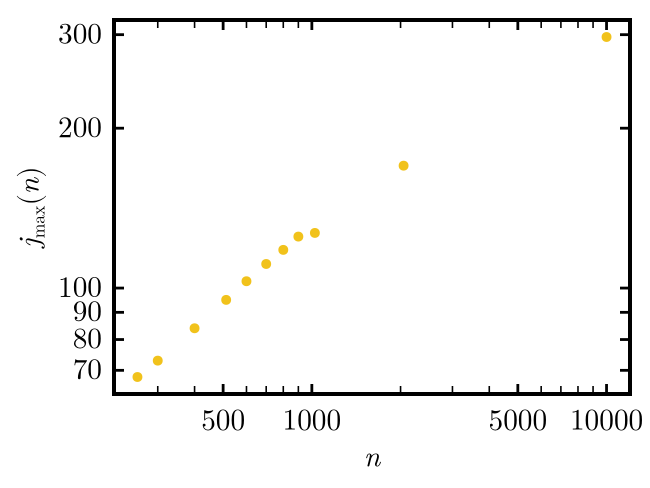

CairoMakie.Screen{IMAGE}


In [31]:
xvals = [256, 300, 400, 512, 600, 700, 800, 900, 1024, 2048, 10000]
figsize = apply_paper_theme!(
    magnification = 1,
    double_column = false,
    logscale_y = true,
    logscale_x = true,
    )
fig= Figure(size = figsize)
ax = Axis(fig[1,1];
    xlabel = L"n",
    ylabel = L"j_{\mathrm{max}}(n)",
    xscale = log10,
    yscale = log10,
    xticks = [100, 500, 1000, 5000, 10000]
    )
scatter!(
    fig[1,1],
    xvals,
    max_bins_man_normalized;
    markersize = 7,
    )
#lines!(
    #fig[1,1],
    #xvals,
    # 5. .* xvals .^ 0.45;
    #color = :red,
    #label = L"j_{\mathrm{max}}(n) \propto n^{0.5}"
    #)
save(fig_path("graph_observables/abundances/man/size_max_bin_power_law.pdf"), fig)

display(fig)

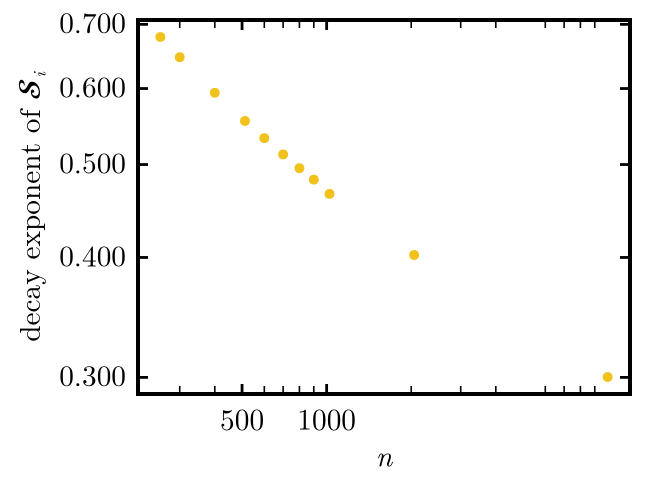

CairoMakie.Screen{IMAGE}


In [14]:
xvals = [256, 300, 400, 512, 600, 700, 800, 900, 1024, 2048, 10000]
figsize = apply_paper_theme!(
    magnification = 1,
    double_column = false,
    logscale_y = true,
    logscale_x = true,
    )
fig= Figure(size = figsize)
ax = Axis(fig[1,1];
    xlabel = L"n",
    ylabel = L"\mathrm{decay~exponent~of~} \mathcal{S}_i",
    xscale = log10,
    yscale = log10,
    xticks = [100, 500, 1000]
    )
scatter!(
    fig[1,1],
    xvals,
    [fit.params.α for fit in fit_res_man_normalized];
    markersize = 7,
    )
save(fig_path("graph_observables/abundances/man/decay_exponents.pdf"), fig)

display(fig)

In [15]:
x0 = 1000
xvals = [256, 300, 400, 512, 600, 700, 800, 900, 1024, 2048, 10000]
average_α = [fit.params.α for fit in fit_res_man_normalized];
fit_α = fit_curve(
    average_α,
    (x, p) ->  p.b .* (x ./ x0)^p.β,
    ( :b, :β);
    x_values = xvals,
    stds = [fit.stderr.α for fit in fit_res_man_normalized],
    minimize_χ² = true,
    init = ( b=1., β=1.),
    #x_values = x_values[i],
    goodness_of_fit = true,
    multistart = 1000,
    rng = MersenneTwister(42),
    return_cov=true,
    bootstrap_errorbars=true
    )

println("χ²: $(fit_α.χ²)")
println("parameters: $(fit_α.params)")
println("parameters: $(fit_α.stderr)")

χ²: 4.412792529655598
parameters: (b = 0.47870359639198823, β = -0.20755536160823124)
parameters: (b = 0.001851515661651162, β = 0.0027986577995616985)


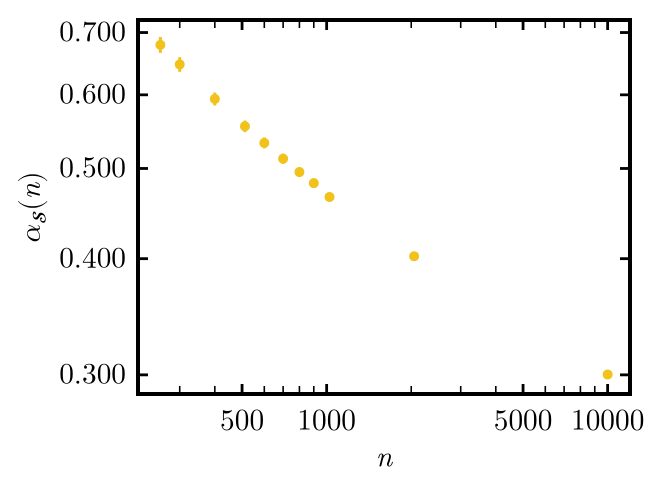

CairoMakie.Screen{IMAGE}


In [34]:
colors_obs = Makie.theme(:palette).color
colors = colors_obs isa Observables.Observable ? Observables.to_value(colors_obs) : colors_obs

figsize = apply_paper_theme!(
    magnification = 1,
    double_column = false,
    logscale_y = true,
    logscale_x = true,
    xticks = [100, 500, 1000, 5000, 10000],
    #yticks = [.6, .65, .7, .75, .8],
    )
fig= Figure(size = figsize)
ax = Axis(fig[1,1];
    xlabel = L"n",
    ylabel = L"\alpha_{\mathcal{S}}(n)",
    xscale = log10,
    yscale = log10,
    )

x_fit = range(200, stop = 15000, length = 200)

y_fit = abs.(fit_α.params.b .* (x_fit ./ x0) .^ fit_α.params.β)

# parameter errors (named tuple)
σb = fit_α.stderr.b
σβ = fit_α.stderr.β

# linearized variance: (∂y/∂a)^2 σa^2 + (∂y/∂b)^2 σb^2 + (∂y/∂β)^2 σβ^2
# y = a + b*x^β, so:
# ∂y/∂a = 1
# ∂y/∂b = x^β
# ∂y/∂β = b * x^β * log(x)
dy = sqrt.(((x_fit ./ x0) .^ fit_α.params.β).^2 .* σb^2 .+
           (fit_α.params.b .* (x_fit ./ x0) .^ fit_α.params.β .* log.(x_fit ./ x0)).^2 .* σβ^2)

y_lo = y_fit .- dy
y_hi = y_fit .+ dy

#band!(ax, x_fit, y_lo, y_hi; color = (colors[2], 0.2))
#lines!(ax, x_fit, y_fit; linewidth = 1, color = colors[2])

scatter!(
    fig[1,1],
    xvals,
    [fit.params.α for fit in fit_res_man_normalized];
    markersize = 7,
    )
errorbars!(ax, 
xvals, 
[fit.params.α for fit in fit_res_man_normalized], 
[fit.stderr.α for fit in fit_res_man_normalized]; direction = :y)
save(fig_path("graph_observables/abundances/man/decay_exponents_with_fit_man_size.pdf"), fig)

display(fig)